# Task 2: Polynomial Regression

Original problem: Build a Machine Learning model that predicts an employee's Salary from Experience, where the relationship between experience and salary is curved rather than a straight line.

In [48]:
# in previous task we were using linear regression using three features 
# Experience , Education, Projects =SALARY PREDICTION


# but in this we will use only one feather which is EXPERIENCE from which we can predict
 # salary and with a curved relationship x x^2 x^4 thats why we gonna use Polynomial regression


Experience
    ↓
    
Polynomial Transformation
    ↓
    
Experience + Experience²
    ↓
    
Linear Regression
    ↓
    
Salary

In [49]:
import pandas as pd 

data={

    "Experience":[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    "Salary":    [30000,35000,41000,50000,62000,
                  77000,94000,114000,137000,163000,
                  192000,224000,259000,297000,338000]
}
df=pd.DataFrame(data)

df

,Experience,Salary
0,1,30000
1,2,35000
2,3,41000
3,4,50000
4,5,62000
5,6,77000
6,7,94000
7,8,114000
8,9,137000
9,10,163000


# understand the relationship 

In [50]:
shape=df.shape
print("shape",shape)
print("\n\n")
info=df.info()
print("info",info)

shape (15, 2)



<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Experience  15 non-null     int64
 1   Salary      15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes
info None


# part C -> Visualize THE DATA using Matplotlib


In [51]:
import matplotlib.pyplot as plt 



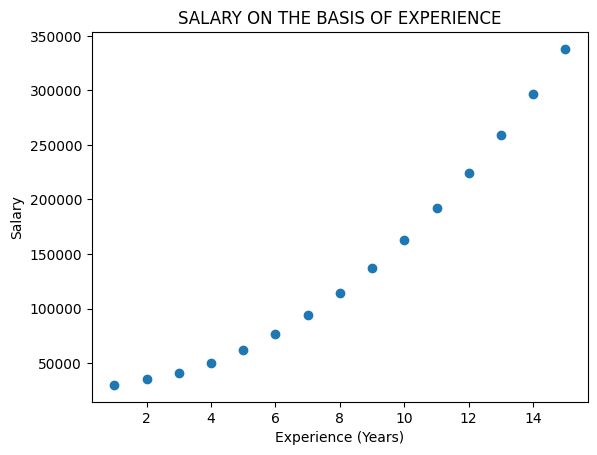

In [52]:
plt.scatter(df["Experience"],df["Salary"])

plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("SALARY ON THE BASIS OF EXPERIENCE")
plt.show()

In [53]:
x=df[["Experience"]] #2d FataFrame
y=df["Salary"]


# X = input/features
# y = target/output

# PART E-> Train/Test Split

In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train,X_test,Y_train,Y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.preprocessing import PolynomialFeatures

# it will create Experience then Experience^2

In [57]:
# we are choosing PolynomialFeatures(degree=2)
# because we want x^2


In [58]:
poly = PolynomialFeatures(degree=2)


# Tranforming the data

# what does fit transformer do?
fit
 ↓

understand the transformation

transform
 ↓

create polynomial features

_______________________________________________________________

1 | Experience | Experience²
--------------------------------
1   |     1      |      1

1 |     2      |      4

1 |     3      |      9

1 |     4      |     16

In [59]:
X_train_poly = poly.fit_transform(X_train)
X_train_poly
# E and its E^2

array([[  1.,  14., 196.],
       [  1.,   6.,  36.],
       [  1.,   9.,  81.],
       [  1.,   3.,   9.],
       [  1.,   2.,   4.],
       [  1.,  15., 225.],
       [  1.,   5.,  25.],
       [  1.,   8.,  64.],
       [  1.,  11., 121.],
       [  1.,  13., 169.],
       [  1.,   4.,  16.],
       [  1.,   7.,  49.]])

# NOW LETTS CREATE THE MODEL

In [60]:
from sklearn.linear_model import LinearRegression

# Important concept

You might think:

"We're doing Polynomial Regression, so why are we importing LinearRegression?"

Because Polynomial Regression works by:

Original X
   ↓
   
Create X²
   ↓
   
Linear Regression

The model ultimately learns:

y=b0 + b1 + X + b2	+ X^2

In [61]:
model=LinearRegression()


# Train The Model

In [62]:
model.fit(X_train_poly,Y_train) #train,target

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,-1321.31, 1445.49]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.216e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[255.49, 2.93, 0. ]"


 X_train_poly
 
      ↓
Experience

Experience²

       +

y_train

      ↓
      
Actual Salary

# Now see What the model Learned 

In [63]:
print("Intercet",model.intercept_)
print("Coefficients",model.coef_)

Intercet 32158.813397061138
Coefficients [    0.         -1321.3051968   1445.48828475]


## coefficient 1 → Experience
coefficient 2 → Experience²

So the model has learned an equation like:

Salary=b0+b1+Experience+b2Experience2

# Prepare the test data
Why transform() and not fit_transform()?

Because we already fitted the polynomial transformation using the training data.

## TRAINING:

fit_transform()

      ↓

learn + transform


TEST:

transform()

      ↓
only t
ransform

We don't want to learn anything new from the test data.

That's an important ML practice.

In [65]:
X_test_poly = poly.transform(X_test)

In [67]:
X_test_poly

array([[  1.,  10., 100.],
       [  1.,  12., 144.],
       [  1.,   1.,   1.]])

In [70]:
y_prediction= model.predict(X_test_poly)

In [72]:
y_prediction

array([163494.58990392, 224453.46403926,  32282.99648501])

# Compare Actual VS  Printed

In [75]:
comparison = pd.DataFrame({
    "Actual Salary":Y_test.values,
    "Predicted Salary":y_prediction})

In [76]:
comparison

,Actual Salary,Predicted Salary
0,163000,163494.589904
1,224000,224453.464039
2,30000,32282.996485


# Model Evaluation Part

## importing metrics

In [81]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import numpy as np

# MAE 

In [89]:
MAE=mean_absolute_error(Y_test,y_prediction)
print("MAE, On average,\n how many rupees away are our predictions from the actual salaries?:\n",MAE)

MAE, On average,
 how many rupees away are our predictions from the actual salaries?:
 1077.016809397691


# MSE

In [88]:
MSE= mean_squared_error(Y_test,y_prediction)
print("MSE:\n",MSE)

MSE:
 1887440.5861768501


# RMSE

In [90]:
RMSE=np.square(MSE)
print("RMSE",RMSE)

RMSE 3562431966347.612


# R2
R² tells us how well the model explains the variation in the target compared with a simple mean-based baseline.

Closer to 1 → predictions explain the data well

Around 0    → little improvement over the baseline

Negative    → worse than the baseline

In [93]:
R2=r2_score(Y_test,y_prediction)
print("R2:",R2)

R2: 0.9997123096352744


# Show everything together

In [94]:
print("Model Evaluation")
print("-----------------")
print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE:", RMSE)
print("R²  :", R2)

Model Evaluation
-----------------
MAE : 1077.016809397691
MSE : 1887440.5861768501
RMSE: 3562431966347.612
R²  : 0.9997123096352744


# Visualize the Polynomial Regression curve
First, create predictions for all original X values:

In [105]:
X_poly=poly.transform(x)
y_curve= model.predict(X_poly)


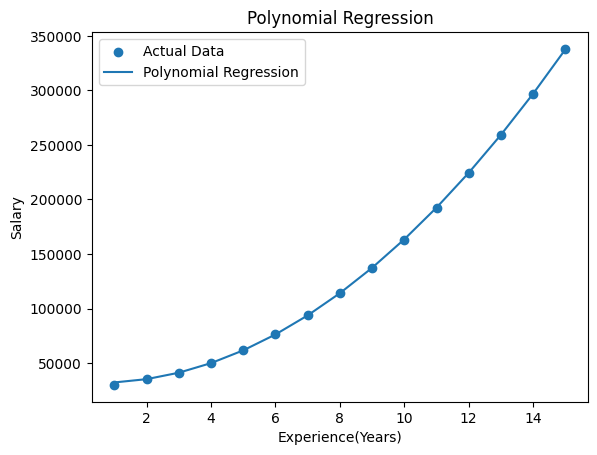

In [107]:
plt.scatter(x,y,label="Actual Data")
plt.plot(x,y_curve,label="Polynomial Regression")

plt.xlabel("Experience(Years)")
plt.ylabel("Salary")
plt.title("Polynomial Regression")

plt.legend()
plt.show()

## So the purpose of X_test is not to train again.

It's there to simulate new data coming to your model after training.

One sentence to remember:

X_train teaches the model; X_test checks whether the model can use that learning on unseen data.